In [ ]:

"""1.隐藏层
仿射变换：是一种带有偏置项的线性变换； softmax回归的模型架构，该模型通过单个仿射变换将我们的输入直接映射到输出， 然后进行softmax操作。
如果我们的标签通过仿射变换后确实与我们的输入数据相关， 那么这种方法确实足够了，但是，仿射变换中的线性是一个很强的假设。


1.1 线性模型可能会出错
    线性意味着单调假设


1.2 在网络中加入隐藏层
我们可以通过在网络中加入一个或多个隐藏层来克服线性模型的限制，使其能处理更普遍的函数关系
类型。要做到这一点，最简单的方法是将许多全连接层堆叠在一起。 每一层都输出到上面的层，直到
生成最后的输出。
把前L-1层看作表示，把最后一层看作线性预测器。 这种架构通常称为多层感知机(multilayer perception).
缩写为MLP.   以下这个多层感知机有4个输入，3个输出，其隐藏层包含5个隐藏单元。 输入层不涉及
任何计算，因此使用网络产生输出只需要实现隐藏层和输出层的计算。因此，这个多层感知机中的层数
为2.注意，这两个层都是全连接的。每个输入都会影响隐藏层中的每个神经元，而隐藏层中的每个神经元
又影响输出层中的每个神经元。

具有全连接层的多层感知机的参数开销可能会高得令人望而却步。即使在不改变输入或输出大小的情况
下，可能在参数节约和模型有效性之间进行权衡。
"""


In [1]:
from IPython.display import Image
Image(url="mlp.png")

In [5]:
"""
1.3 从线性到非线性

"""
Image(url="多层感知机_非线性.png")

In [ ]:
"""
1.4 通用近似定理
多层感知机可以通过隐藏神经元，捕捉到输入之间复杂的相互作用，这些神经元依赖于每个输入的值。

虽然一个单隐层网络能学习任何函数，单并不意味着我们应该尝试使用单隐层网络来解决所有问题。
事实上， 通过使用更深(而不是更广)的网络， 我们可以更容易地逼近许多函数
"""

In [6]:
"""
2. 激活函数(activation function) 通过计算加权和并加上偏置来确定神经元是否应该被激活，它们
将输入信号转换为输出的可微运算。 大多数激活函数都是非线性的。
"""
%matplotlib inline
import torch
from d2l import torch as d2l


In [7]:
"""
2.1 ReLU函数
最受欢迎的激活函数是修正线性单元(Rectified linear unit, ReLU), 因为它实现简单，同时在
各种预测任务中表现良好。 ReLU提供了一种非常简单的非线性变换。给定元素x，ReLU函数被定义
为该元素与0的最大值：

通俗地讲，ReLU函数通过将相应的活性值设为0，仅保留正元素并丢弃所有负元素。
"""
Image(url="ReLU_formula.png")

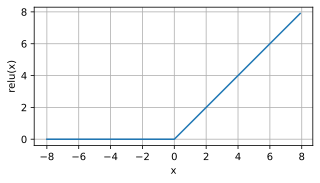

In [8]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))

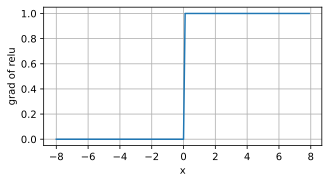

In [9]:
"""
当输入为负时， ReLU函数的导数为0， 而当输入为正时， ReLU函数的导数为1.注意，当输入值精确
等于0时，ReLU函数不可导。在此时，我们默认使用左侧的导数，即当输入为0时导数为0.我们可以忽略
这种情况，因为输入可能永远都不会是0.
"""
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

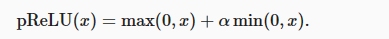

In [10]:
"""
使用ReLU的原因是，它求导表现得非常好：要么让参数消失， 要么让参数通过。这使得优化表现
得更好，并且ReLU减轻了困扰以往神经网络的梯度消失问题

注意：ReLU函数有许多变体，包括参数化ReLU(Parameterized ReLU, pReLU)函数。 该变体为
ReLU添加了一个线性项，因此即使参数是负的，某些信息仍然可以通过:

"""
Image("PReLU_formula.png")

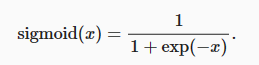

In [11]:
"""
2.2 sigmoid函数

对于一个定义域在R中的输入，sigmoid函数将输入变换为区间(0,1)上的输出，因此， sigmoid函数
通常称为挤压函数(squashing function):它将范围(-inf, inf)中的任意输入压缩到区间(0,1)中
的某个值：

在最早的神经网络中，科学家们感兴趣的是对"激发"或"不激发"的生物神经元进行建模。因此，这一领域
的先驱可以一直追溯到人工神经元的发明者麦卡洛克和皮茨，他们专注于阈值单元。阈值单元在其输入
低于某个阈值时取值0，当输入超出阈值时取值1.

当人们逐渐关注到基于梯度的学习时， sigmoid函数是一个自然的选择，因为它是一个平滑的，可微的
阈值单元近似。当我们想要将输出视为二分类问题的概率时，sigmoid仍然被广泛用作输出单元上
的激活函数(sigmoid可以视为softmax的特例)。 然而，sigmoid在隐藏层中已经较少使用，它在大部分
时候被更简单，更容易训练的ReLU所取代。 在循环神经网络，将利用sigmoid单元来控制时序
信息流的架构。
"""
Image("sigmoid.png")

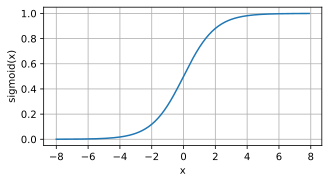

In [12]:
# 当输入接近0时， sigmoid函数接近线性变换
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

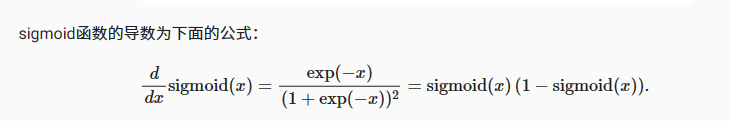

In [13]:
Image("sigmoid_derivative.png")

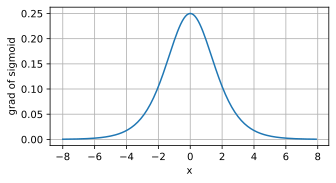

In [14]:
# 当输入为0时， sigmoid函数的导数达到最大值0.25； 而输入在任一方向上越远离0点时， 导数
# 越接近于0
# 清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

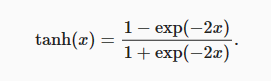

In [15]:
"""
2.3 tanh函数
与sigmoid函数类似，tanh(双曲正切)函数也能将其输入压缩转换到区间(-1, 1)上， tanh函数的公式
如下：
"""
Image("tanh_formula.png")

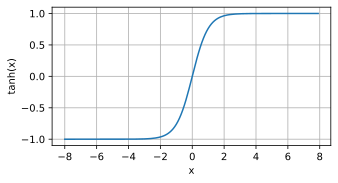

In [16]:
"""
当输入在0附近时， tanh函数接近线性变换。函数的形状类似于sigmoid函数，不同的是tanh函数
关于坐标系原点中心对称。
"""
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))


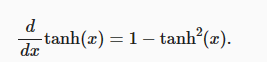

In [17]:
"""
tanh函数的导数是：
"""
Image("tanh_derivative.png")

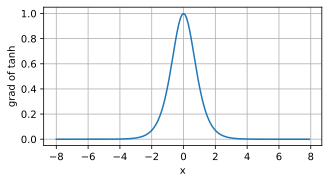

In [18]:
"""
tanh函数的导数图像如下所示。当输入接近0时，tanh函数的导数接近最大值1.与我们在sigmoid函数
图像中看到的类似，输入在任一方向上越远离0点，导数越接近0
"""
# 清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize=(5, 2.5))

In [ ]:
"""小结
多层感知机在输出层和输入层之间增加一个或多个全连接隐藏层，并通过激活函数转换隐藏层的输出
常用的激活函数包括ReLU函数，sigmoid函数和tanh函数
"""